# Training Convolutional Neural Networks

## Part 5 of 5: Loading a ResNet From TorchHub

- Loading a model from the PyTorch Hub: https://pytorch.org/docs/stable/hub.html

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(123)

In [2]:
entrypoints = torch.hub.list('pytorch/vision', force_reload=True)
for e in entrypoints:
    print(e)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /home/zeus/.cache/torch/hub/main.zip
alexnet
convnext_base
convnext_large
convnext_small
convnext_tiny
deeplabv3_mobilenet_v3_large
deeplabv3_resnet101
deeplabv3_resnet50
densenet121
densenet161
densenet169
densenet201
efficientnet_b0
efficientnet_b1
efficientnet_b2
efficientnet_b3
efficientnet_b4
efficientnet_b5
efficientnet_b6
efficientnet_b7
efficientnet_v2_l
efficientnet_v2_m
efficientnet_v2_s
fcn_resnet101
fcn_resnet50
get_model_weights
get_weight
googlenet
inception_v3
lraspp_mobilenet_v3_large
maxvit_t
mc3_18
mnasnet0_5
mnasnet0_75
mnasnet1_0
mnasnet1_3
mobilenet_v2
mobilenet_v3_large
mobilenet_v3_small
mvit_v1_b
mvit_v2_s
r2plus1d_18
r3d_18
raft_large
raft_small
regnet_x_16gf
regnet_x_1_6gf
regnet_x_32gf
regnet_x_3_2gf
regnet_x_400mf
regnet_x_800mf
regnet_x_8gf
regnet_y_128gf
regnet_y_16gf
regnet_y_1_6gf
regnet_y_32gf
regnet_y_3_2gf
regnet_y_400mf
regnet_y_800mf
regnet_y_8gf
resnet101
resnet152
resnet18
resnet34
r

In [10]:
model = torch.hub.load("pytorch/vision", "resnet18", weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

Using cache found in /home/zeus/.cache/torch/hub/pytorch_vision_main


In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full   = torchvision.datasets.CIFAR10(root="data/", train=True,  download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

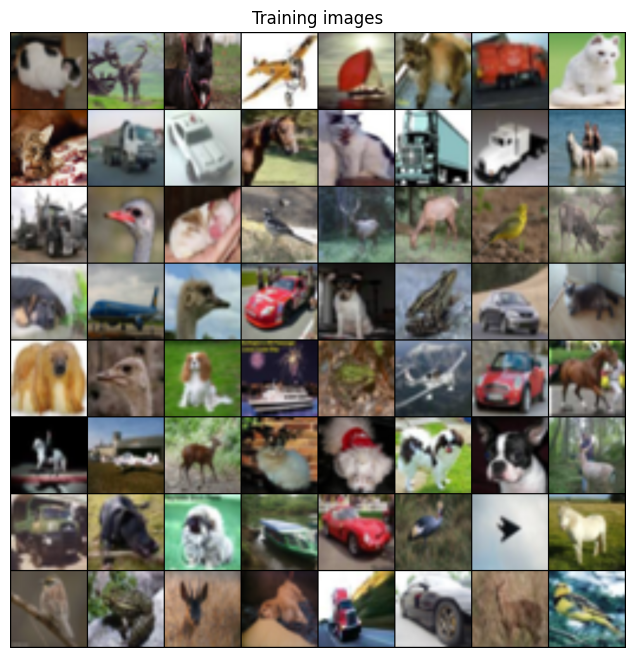

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(images[:64], padding=2, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [7]:
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [11]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-torchhub-cifar10")

dummy = torch.zeros(1, 3, 128, 128).to(device)
writer.add_graph(model, dummy)

In [ ]:
MAX_EPOCHS = 50

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()

Epoch 01/50 | Train Loss: 1.8447  Acc: 0.3366 | Val Loss: 1.6134  Acc: 0.4182
Epoch 02/50 | Train Loss: 1.2838  Acc: 0.5343 | Val Loss: 1.2188  Acc: 0.5700
Epoch 03/50 | Train Loss: 0.9969  Acc: 0.6480 | Val Loss: 1.0634  Acc: 0.6382
Epoch 04/50 | Train Loss: 0.8005  Acc: 0.7186 | Val Loss: 1.0073  Acc: 0.6556
Epoch 05/50 | Train Loss: 0.6525  Acc: 0.7732 | Val Loss: 0.7934  Acc: 0.7290
Epoch 06/50 | Train Loss: 0.5286  Acc: 0.8142 | Val Loss: 0.7510  Acc: 0.7366
Epoch 07/50 | Train Loss: 0.4230  Acc: 0.8503 | Val Loss: 0.7204  Acc: 0.7636
Epoch 08/50 | Train Loss: 0.3406  Acc: 0.8805 | Val Loss: 0.6790  Acc: 0.7798
Epoch 09/50 | Train Loss: 0.2716  Acc: 0.9049 | Val Loss: 0.8355  Acc: 0.7548
Epoch 10/50 | Train Loss: 0.2125  Acc: 0.9244 | Val Loss: 0.8335  Acc: 0.7638
Epoch 11/50 | Train Loss: 0.1750  Acc: 0.9390 | Val Loss: 0.7944  Acc: 0.7756


In [ ]:
test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
te_loss, te_acc = evaluate(model, test_loader, criterion, test_acc, device)
print(f"\nTest Loss: {te_loss:.4f} | Test Accuracy: {te_acc:.4f}")
